**Chargement et exploration des données**

In [93]:
import pandas as pd
import numpy as np

In [94]:
data = pd.read_csv('train.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [96]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [97]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


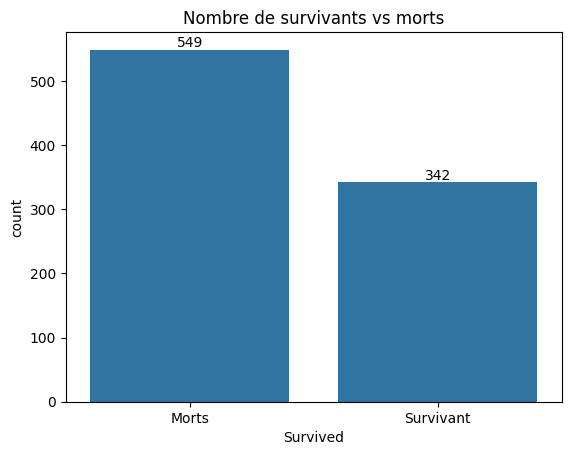

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(x='Survived', data=data)
plt.title('Nombre de survivants vs morts')
plt.xticks([0, 1], ['Morts', 'Survivant'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

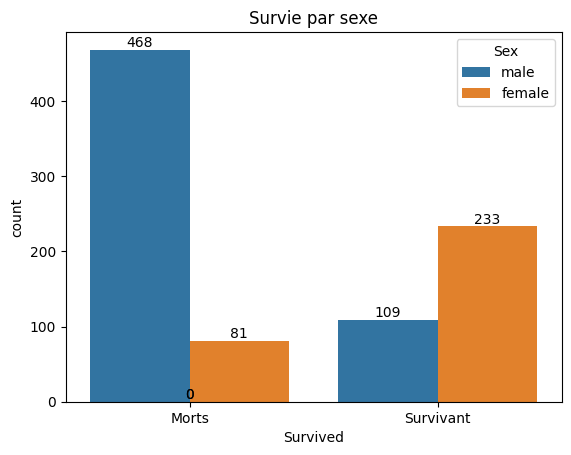

In [99]:
ax = sns.countplot(x='Survived', hue='Sex', data=data)
plt.title('Survie par sexe')
plt.xticks([0, 1], ['Morts', 'Survivant'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

1.   Morts hommes → très haute
2.   Morts femmes → petite
1.   Survivants hommes → petite
2.   Survivants femmes → très haute


Cela confirme "Women and children first" était réel. Les femmes ont survécu massivement, les hommes beaucoup moins.

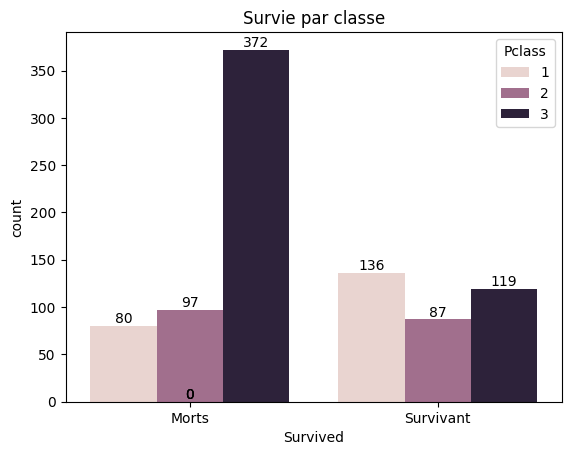

In [100]:
ax = sns.countplot(x='Survived', hue='Pclass', data=data)
plt.title('Survie par classe')
plt.xticks([0, 1], ['Morts', 'Survivant'])

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

La richesse protégeait. Les passager de 1ère classe avaient accès aux canots de sauvetage en priorité.

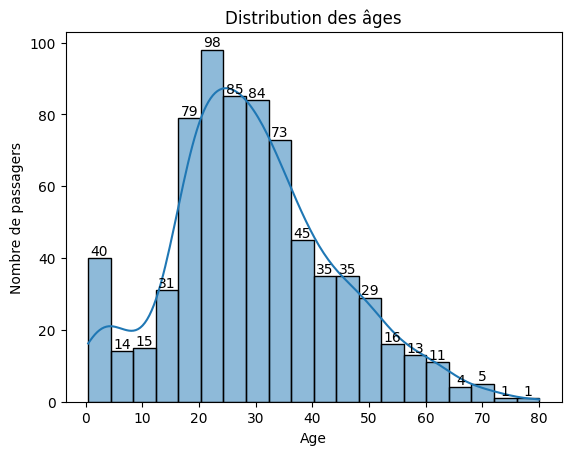

In [101]:
ax = sns.histplot(data['Age'], bins=20, kde=True)
plt.title('Distribution des âges')
plt.xlabel('Age')
plt.ylabel('Nombre de passagers')

for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

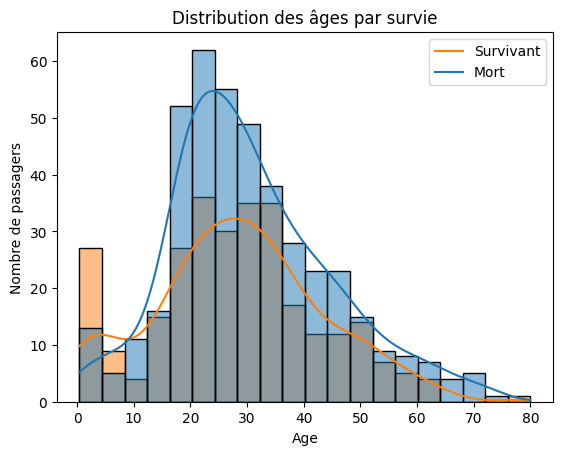

In [102]:
sns.histplot(data=data, x='Age', hue='Survived', bins=20, kde=True,)

plt.title('Distribution des âges par survie')
plt.xlabel('Age')
plt.ylabel('Nombre de passagers')
plt.legend(labels=['Survivant', 'Mort'])
plt.show()

*   Les enfants de 0 à 10 ans — plus de survivants que de morts. Les enfants étaient prioritaires.
*   Les 20-30 ans — beaucoup de morts.
*   Les 50-60 ans — légèrement plus de survivants. Probablement des riches en 1ère classe.




**Nettoyage des données**

In [103]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [104]:
data = data.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [105]:
#remplir les valeurs manquantes d'âge par median

data['Age'] = data['Age'].fillna(data['Age'].median())

print(data['Age'].isnull().sum())

0


In [106]:
#remplir les valeurs manquantes d'Embarked
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
print(data['Embarked'].isnull().sum())
print(data['Embarked'].value_counts())

0
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


pourquoi mode et pas mediane ?

Embarked contient du texte S,C et Q. On ne peut pas calculer une médiane de lettres. On remplace les manquants par la valeur la plus courante, ici S.



In [107]:
data.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [108]:
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})

In [109]:
embarked_dummies = pd.get_dummies(data['Embarked'], prefix='Embarked', dtype=int)
print(embarked_dummies.head())

   Embarked_C  Embarked_Q  Embarked_S
0           0           0           1
1           1           0           0
2           0           0           1
3           0           0           1
4           0           0           1


In [110]:
#ajouter les colonnes Embarked dans data
data = pd.concat([data, embarked_dummies], axis=1)

if 'Embarked' in data.columns:
    data = data.drop(columns=['Embarked'])

print(data.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
0         0       3    0  22.0      1      0   7.2500           0           0   
1         1       1    1  38.0      1      0  71.2833           1           0   
2         1       3    1  26.0      0      0   7.9250           0           0   
3         1       1    1  35.0      1      0  53.1000           0           0   
4         0       3    0  35.0      0      0   8.0500           0           0   

   Embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  


In [113]:
X = data.drop(columns=['Survived'])
y = data['Survived']

print ("X shape:", X.shape)
print("Y shape:", y.shape)

X shape: (891, 9)
Y shape: (891,)


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)
#test_size=0.2 il s'agit de 20% des données pour tester, 80% pour entraîner.

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (712, 9)
X_test: (179, 9)


In [118]:
#entraôner le modèle Random Forest

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [119]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print("Accuracy:", round(score*100, 2), "%")

Accuracy: 81.01 %


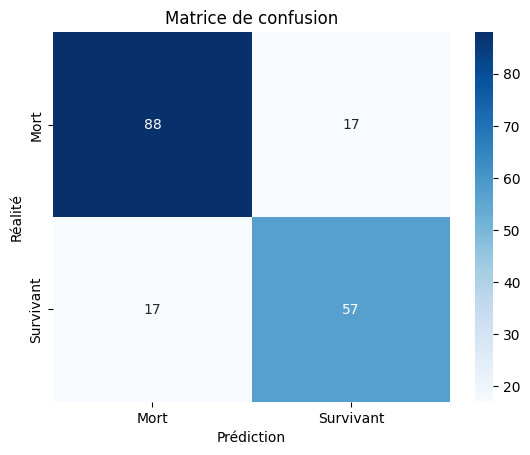

In [120]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mort', 'Survivant'],
            yticklabels=['Mort', 'Survivant'])

plt.title('Matrice de confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.show()

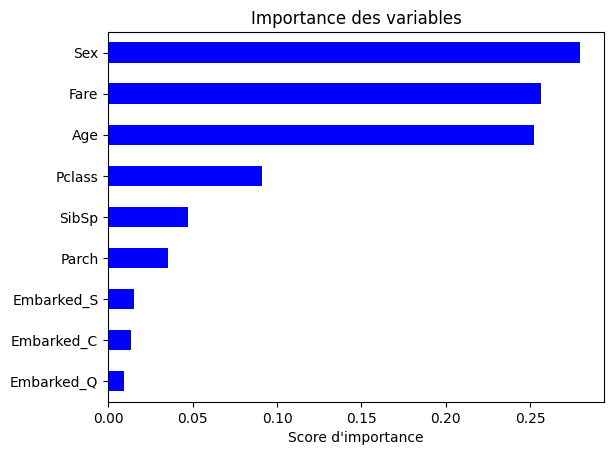

In [125]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)


importances.plot(kind='barh', color='blue')
plt.title('Importance des variables')
plt.xlabel('Score d\'importance')
plt.show()

In [139]:
test_data = pd.read_csv('test.csv')

test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

embarked_dummies_test = pd.get_dummies(test_data['Embarked'], prefix='Embarked', dtype=int)
test_data = pd.concat([test_data, embarked_dummies_test], axis=1)
test_data = test_data.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId', 'Embarked'])

predictions = model.predict(test_data)

submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test.csv')['PassengerId'],
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0
